# FashionIQ
## Data Understanding (Notebook 01)

**Project**: FashionIQ — End-to-End Fashion Sales Analytics

**Goal**: Perform a complete *Data Understanding* workflow (structure, profiling, data quality assessment) to inform **Data Cleaning**.

**Scope constraints**: No cleaning/repairing, no persistent type conversion, no feature engineering, no EDA/business insights, no modeling.

---
## Project Metadata

- **Notebook**: `01_data_understanding.ipynb`
- **Project**: FashionIQ
- **Version**: 1.2
- **Date**: 2026-07-13
- **Dataset**: `data/fashion_sales.csv`


In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

---

## 1. Load Dataset

*Why*: Ensure the dataset loads correctly and the notebook stays portable.

*How*: Uses relative path with graceful error handling.

In [ ]:
DATA_PATH = Path('../data/raw/fashion_sales.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

# CSV delimiter is ';' (Excel-style).
df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig')

print(f'Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('Columns:', list(df.columns))

FileNotFoundError: Dataset not found: C:\Users\ASUS GAMING\VSCode\fashion-sales-analytics-pipeline\data\fashion_sales.csv

---

## 2. Data Dictionary

Documentation scaffolding to clarify intended meaning of each column for the next stages.

> Note: This does not modify the dataset.

In [ ]:
data_dictionary = [
    ('Order ID', 'Unique order identifier (header-level id)'),
    ('Order Date', 'Order timestamp (text in raw file)'),
    ('Customer Name', 'Customer name (no Customer ID provided)'),
    ('City', 'Customer city / location'),
    ('Product Name', 'Purchased product / item name'),
    ('Unit Price', 'Item unit price (Rupiah formatting in raw file)'),
    ('Quantity', 'Number of units in this order-item line'),
    ('Discount (%)', 'Discount percentage applied to the line'),
    ('Subtotal', 'Subtotal before discount (Rupiah)'),
    ('Discount Amount', 'Discount amount (Rupiah)'),
    ('Total Sales', 'Line sales after discount (Rupiah)'),
    ('Shipping Fee', 'Shipping fee for the order (Rupiah)'),
    ('Grand Total', 'Order total (Subtotal/Total Sales + shipping)'),
    ('Payment Method', 'Payment channel used'),
    ('Order Status', 'Order status'),
    ('Platform', 'Sales platform / channel'),
    ('Customer Rating', 'Rating value (1–5 scale)'),
    ('Size', 'Product size'),
    ('Material', 'Material / fabric type'),
    ('Gender', 'Target gender for the product')
]

ddf = pd.DataFrame(data_dictionary, columns=['Column', 'Description'])
display(ddf[ddf['Column'].isin(df.columns)].reset_index(drop=True))

,Column,Description
0,Order ID,Unique order identifier (header-level id)
1,Order Date,Order timestamp (text in raw file)
2,Customer Name,Customer name (no Customer ID provided)
3,City,Customer city / location
4,Product Name,Purchased product / item name
5,Unit Price,Item unit price (Rupiah formatting in raw file)
6,Quantity,Number of units in this order-item line
7,Discount (%),Discount percentage applied to the line
8,Subtotal,Subtotal before discount (Rupiah)
9,Discount Amount,Discount amount (Rupiah)


---

## 3. Dataset Overview

*Outputs*: schema (shape, column names, dtypes) and memory footprint.


In [ ]:
print('Shape:', df.shape)
print('Rows:', f'{df.shape[0]:,}')
print('Columns:', df.shape[1])
print('--- df.info() ---')
df.info()

mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f'Estimated memory usage: {mem_mb:.2f} MB')

Shape: (15000, 20)
Rows: 15,000
Columns: 20
--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order ID         15000 non-null  str    
 1   Order Date       15000 non-null  str    
 2   Customer Name    15000 non-null  str    
 3   City             15000 non-null  str    
 4   Product Name     15000 non-null  str    
 5   Unit Price       15000 non-null  float64
 6   Quantity         15000 non-null  int64  
 7   Discount (%)     15000 non-null  int64  
 8   Subtotal         15000 non-null  str    
 9   Discount Amount  15000 non-null  float64
 10  Total Sales      15000 non-null  str    
 11  Shipping Fee     15000 non-null  float64
 12  Grand Total      15000 non-null  str    
 13  Payment Method   15000 non-null  str    
 14  Order Status     15000 non-null  str    
 15  Platform         15000 non-null  str    
 16  Custome

---

## 4. Data Preview

*Why*: Confirms loading format and dataset grain.

In [ ]:
display(df.head(3))
display(df.tail(3))
display(df.sample(5, random_state=42))

,Order ID,Order Date,Customer Name,City,Product Name,Unit Price,Quantity,Discount (%),Subtotal,Discount Amount,Total Sales,Shipping Fee,Grand Total,Payment Method,Order Status,Platform,Customer Rating,Size,Material,Gender
0,ORD00001,13/12/2025 16:02,Clara Ananda,Pontianak,Rok Midi,185.0,3,0,555.000,0.0,555.000,17.0,883.000,Transfer Bank,Completed,Toko Fashion App,3,XL,Polyester,Wanita
1,ORD00001,13/12/2025 16:02,Clara Ananda,Pontianak,Kemeja Formal,311.0,1,0,311.000,0.0,311.000,17.0,883.000,Transfer Bank,Completed,Toko Fashion App,3,XXL,Katun Oxford,Pria
2,ORD00002,28/10/2025 13:57,Qori Syahputra,Manokwari,Jaket Denim,490.0,1,0,490.000,0.0,490.000,24.0,2.228.000,e-Wallet,Completed,StyleMart,2,L,Chambray,Pria


,Order ID,Order Date,Customer Name,City,Product Name,Unit Price,Quantity,Discount (%),Subtotal,Discount Amount,Total Sales,Shipping Fee,Grand Total,Payment Method,Order Status,Platform,Customer Rating,Size,Material,Gender
14997,ORD05000,01/03/2025 14:32,Iwan Budiman,Padang,Jaket Bomber,452.0,1,0,452.000,0.0,452.000,27.0,2.360.000,Transfer Bank,Completed,StyleMart,2,XXL,Scuba,Pria
14998,ORD05000,01/03/2025 14:32,Iwan Budiman,Padang,Sweater,304.0,1,0,304.000,0.0,304.000,27.0,2.360.000,Transfer Bank,Completed,StyleMart,2,XXL,Acrylic,Pria
14999,ORD05000,01/03/2025 14:32,Iwan Budiman,Padang,Kaos Polo,203.0,3,0,609.000,0.0,609.000,27.0,2.360.000,Transfer Bank,Completed,StyleMart,2,S,Katun Pique,Pria


,Order ID,Order Date,Customer Name,City,Product Name,Unit Price,Quantity,Discount (%),Subtotal,Discount Amount,Total Sales,Shipping Fee,Grand Total,Payment Method,Order Status,Platform,Customer Rating,Size,Material,Gender
11499,ORD03834,15/11/2025 14:33,Budi Fauziah,Kendari,Kemeja Casual,232.0,2,0,464.000,0.0,464.000,22.0,1.234.000,e-Wallet,Completed,Toko Fashion App,1,M,Katun,Pria
6475,ORD02152,30/09/2025 11:44,Yani Ananda,Kupang,Celana Jeans,513.0,1,0,513.000,0.0,513.000,17.0,969.000,Transfer Bank,Completed,FashionKita,3,XL,Stretch Denim,Pria
13167,ORD04393,02/02/2025 21:06,Citra Kurniawan,Semarang,Sweater,434.0,2,10,868.000,86.8,781.200,27.0,1.741.500,Kartu Kredit,Completed,FashionKita,5,L,Wool,Pria
862,ORD00291,02/07/2025 20:11,Tono Fauziah,Banda Aceh,Hoodie,220.0,2,0,440.000,0.0,440.000,27.0,2.286.000,COD,Completed,FashionHub,3,L,Cotton Combed,Pria
5970,ORD01985,06/04/2025 12:38,Dewi Hidayat,Surabaya,Kaos Polo,167.0,1,0,167.000,0.0,167.000,24.0,1.251.000,Transfer Bank,Completed,OutfitNow,3,M,Lacoste Cotton,Pria


---

## 5. Data Profiling

This section quantifies dataset quality signals (missingness, duplicates, cardinality, and basic summaries).


### 5.1 Missing Value Analysis (with visual profiling)

*Why*: Missingness can change aggregation logic and metric validity.

,missing_count,missing_pct
Order ID,0,0.0
Order Date,0,0.0
Customer Name,0,0.0
City,0,0.0
Product Name,0,0.0
Unit Price,0,0.0
Quantity,0,0.0
Discount (%),0,0.0
Subtotal,0,0.0
Discount Amount,0,0.0


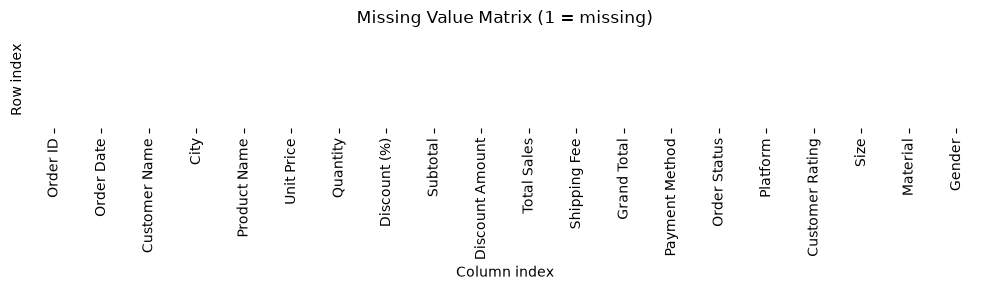

In [ ]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
display(missing_report.head(15))

plt.figure(figsize=(10, 3))
missing_matrix = df.isna().astype(int)
sns.heatmap(missing_matrix, cbar=False, cmap='Greys', yticklabels=False)
plt.title('Missing Value Matrix (1 = missing)')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.tight_layout()
plt.show()

### 5.2 Duplicate Analysis

*Levels*: full-row duplicates and duplicates on the order-item key (`Order ID` + `Product Name`).

In [ ]:
full_duplicates = int(df.duplicated().sum())
order_item_key = ['Order ID', 'Product Name']
order_item_duplicates = 0

if set(order_item_key).issubset(df.columns):
    order_item_duplicates = int(df.duplicated(subset=order_item_key).sum())

print('Full-row duplicates:', full_duplicates)
print('Duplicate (Order ID + Product Name):', order_item_duplicates)

Full-row duplicates: 0
Duplicate (Order ID + Product Name): 0


### 5.3 Cardinality & dtype Profiling (visual)

*Why*: Helps detect identifiers and potential inconsistent categorical entries.

,column,unique_values,unique_pct
0,Order ID,5000,33.33
1,Order Date,4966,33.11
2,Grand Total,2144,14.29
3,Total Sales,1511,10.07
4,Subtotal,1124,7.49
5,Unit Price,818,5.45
6,Discount Amount,455,3.03
7,Customer Name,395,2.63
8,City,38,0.25
9,Material,29,0.19


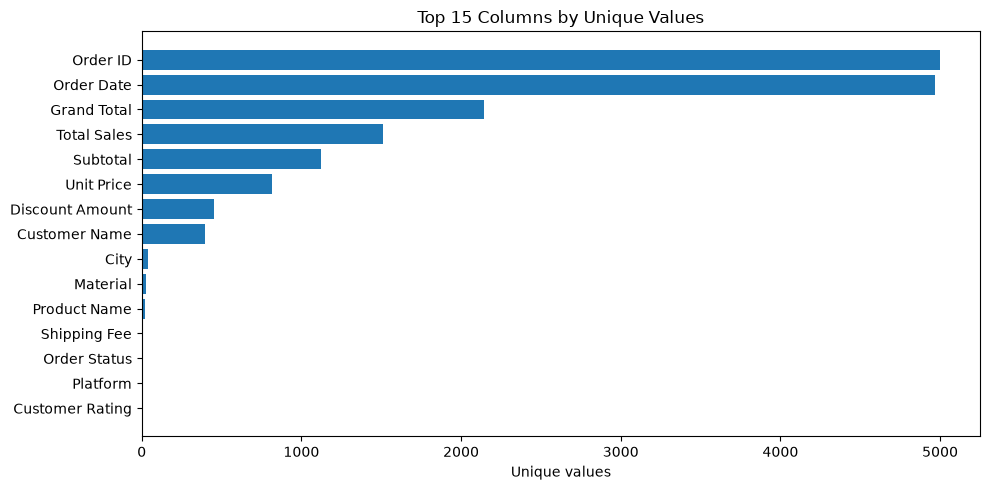

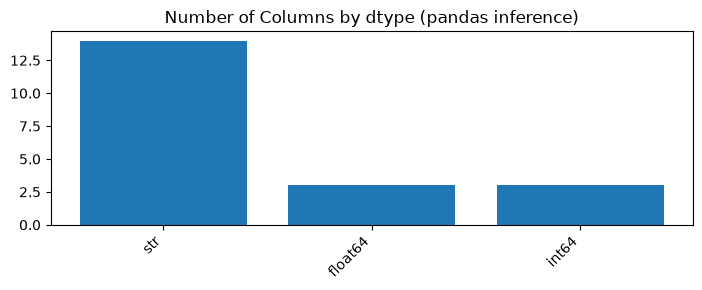

In [ ]:
card = df.nunique(dropna=False).sort_values(ascending=False)
card_df = card.to_frame('unique_values')
card_df['unique_pct'] = (card_df['unique_values'] / len(df) * 100).round(2)
display(card_df.head(15).reset_index().rename(columns={'index': 'column'}))

# Visual: top 15 cardinalities
topk = card_df.sort_values('unique_values').tail(15)
plt.figure(figsize=(10, 5))
plt.barh(topk.index.astype(str), topk['unique_values'])
plt.title('Top 15 Columns by Unique Values')
plt.xlabel('Unique values')
plt.tight_layout()
plt.show()

dtype_counts = df.dtypes.astype(str).value_counts()
plt.figure(figsize=(7, 3))
plt.bar(dtype_counts.index.astype(str), dtype_counts.values)
plt.title('Number of Columns by dtype (pandas inference)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Numerical Summary & Categorical Summary

*Why*: Provides quick statistical context for later data-quality flags.

In [ ]:
num_df = df.select_dtypes(include=[np.number])
print('Numeric columns detected:', list(num_df.columns))
if not num_df.empty:
    display(num_df.describe())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical (object) columns detected:', len(cat_cols))

for c in [x for x in ['Order Status','Payment Method','Platform','Gender','Size','Discount (%)','Customer Rating'] if x in df.columns]:
    print(f'--- {c} (top 8) ---')
    display(df[c].value_counts().head(8).to_frame('count'))

Numeric columns detected: ['Unit Price', 'Quantity', 'Discount (%)', 'Discount Amount', 'Shipping Fee', 'Customer Rating']


,Unit Price,Quantity,Discount (%),Discount Amount,Shipping Fee,Customer Rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,289.561733,1.763533,0.481333,2.267640,23.838000,2.968667
std,151.076606,0.818654,2.140551,11.466046,3.355469,1.408196
min,39.000000,1.000000,0.000000,0.000000,17.000000,1.000000
25%,184.000000,1.000000,0.000000,0.000000,22.000000,2.000000
50%,264.000000,2.000000,0.000000,0.000000,24.000000,3.000000
75%,363.000000,2.000000,0.000000,0.000000,27.000000,4.000000
max,897.000000,4.000000,10.000000,156.800000,27.000000,5.000000


Categorical (object) columns detected: 14
--- Order Status (top 8) ---


C:\Users\ASUS GAMING\AppData\Local\Temp\ipykernel_17380\2727422553.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


,count
Order Status,
Completed,10280
Returned,2067
Cancelled,1109
Shipped,800
Pending,744


...

,count
Size,
L,4258
XL,3470
M,2919
XXL,2511
S,1842


--- Discount (%) (top 8) ---


,count
Discount (%),
0,14278
10,722


--- Customer Rating (top 8) ---


,count
Customer Rating,
4,3335
2,3099
1,3092
5,2739
3,2735


---

## 6. Data Quality Assessment (Identification Only)

We flag potential issues for the next notebook. No cleaning operations are performed here.

### Key Findings (Fast Scan)

- ✅ No missing values detected (based on `df.isna().sum()`).
- ✅ No full-row duplicates detected.
- ✅ No duplicate `Order ID + Product Name` lines detected.
- ⚠ Financial columns may be parsed inconsistently due to Rupiah thousands separator (`.`).
- ⚠ `Customer Name` may not be a reliable unique identifier (no `Customer ID`).

In [ ]:
print('Total missing values:', int(df.isna().sum().sum()))
print('Full-row duplicates:', int(df.duplicated().sum()))
if {'Order ID','Product Name'}.issubset(df.columns):
    print('Duplicate (Order ID + Product Name):', int(df.duplicated(subset=['Order ID','Product Name']).sum()))

Total missing values: 0
Full-row duplicates: 0
Duplicate (Order ID + Product Name): 0


### Financial Locale Parsing Risk (identification)

Inspect dot-frequency in raw text for financial columns. This helps explain why pandas might infer mixed dtypes.

In [ ]:
raw_text = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig', dtype=str)
check_cols = [c for c in ['Unit Price','Subtotal','Discount Amount','Total Sales','Shipping Fee','Grand Total'] if c in raw_text.columns]
for c in check_cols:
    dot_counts = raw_text[c].astype(str).str.count(r'\.').value_counts().sort_index()
    print(f"Dot-count distribution for {c}: ")
    display(dot_counts.to_frame('count'))

Dot-count distribution for Unit Price: 


,count
Unit Price,
1,15000


Dot-count distribution for Subtotal: 


,count
Subtotal,
1,14478
2,522


Dot-count distribution for Discount Amount: 


...

,count
Total Sales,
1,14490
2,510


Dot-count distribution for Shipping Fee: 


,count
Shipping Fee,
1,15000


Dot-count distribution for Grand Total: 


,count
Grand Total,
1,2908
2,12092


### Logical Consistency Checks (checks only; no cleaning)

- `Subtotal` should equal `Unit Price * Quantity`
- `Total Sales` should equal `Subtotal - Discount Amount`

In [ ]:
def parse_rupiah(text_series: pd.Series) -> pd.Series:
    cleaned = text_series.astype(str).str.replace('.', '', regex=False)
    return pd.to_numeric(cleaned, errors='coerce')

required = ['Unit Price','Quantity','Subtotal','Discount (%)','Discount Amount','Total Sales','Shipping Fee','Grand Total']
missing = [c for c in required if c not in raw_text.columns]
if missing:
    print('Missing columns for logical checks:', missing)
else:
    unit_price = parse_rupiah(raw_text['Unit Price'])
    quantity = pd.to_numeric(raw_text['Quantity'], errors='coerce')
    subtotal = parse_rupiah(raw_text['Subtotal'])
    discount_pct = pd.to_numeric(raw_text['Discount (%)'], errors='coerce')
    discount_amount = parse_rupiah(raw_text['Discount Amount'])
    total_sales = parse_rupiah(raw_text['Total Sales'])
    shipping_fee = parse_rupiah(raw_text['Shipping Fee'])
    grand_total = parse_rupiah(raw_text['Grand Total'])

    subtotal_mismatch = int((subtotal != unit_price * quantity).sum())
    discount_mismatch = int((discount_amount != (subtotal * discount_pct / 100).round(0)).sum())
    total_sales_mismatch = int((total_sales != (subtotal - discount_amount)).sum())

    print('Subtotal mismatch count:', subtotal_mismatch)
    print('Discount Amount mismatch count:', discount_mismatch)
    print('Total Sales mismatch count:', total_sales_mismatch)

Subtotal mismatch count: 0
Discount Amount mismatch count: 0
Total Sales mismatch count: 0


### `Customer Name` identifier reliability

No `Customer ID` exists. We test whether the same name spans multiple cities at the order level (proxy stability check).

In [ ]:
if {'Order ID','Customer Name','City'}.issubset(df.columns):
    orders_unique = df.drop_duplicates('Order ID', keep='first')
    city_nunique = orders_unique.groupby('Customer Name')['City'].nunique()
    print('Customer names appearing in >1 city:', int((city_nunique > 1).sum()))
    print('Total unique customer names:', int(city_nunique.shape[0]))
else:
    print('Required columns for customer reliability check are missing.')

Customer names appearing in >1 city: 391
Total unique customer names: 395


---

## 7. Initial Observations (factual, not business insights)

- Dataset grain appears to be **order-item** (multiple products per `Order ID`).
- Missingness is zero based on profiling checks.
- No duplicates are detected at tested levels.
- Primary risks for the next stage: numeric locale parsing for Rupiah financial fields; categorical standardization; customer identifier limitations.

---

## 8. Next Steps

This notebook completes **Data Understanding**.

**Next notebook**: `02_data_cleaning.ipynb`
Expected focus: correct numeric parsing for Rupiah fields, convert `Order Date` to datetime, standardize categorical values (e.g., `Material`), and re-check key invariants.